In [1]:
import os
import sys

sys.path.append("../")

envkey = "OMP_NUM_THREADS"
# Set this environment variable to the number of available cores in your machine,
# to get a fast execution of the Einstein Boltzmann Solver
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))
os.environ[envkey] = str(12)
os.environ[envkey] = str(12)
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))

The value of OMP_NUM_THREADS is:  None
The value of OMP_NUM_THREADS is:  12


In [2]:
import astropy.units as u
import astropy.constants as c
import matplotlib.pyplot as plt
from copy import copy, deepcopy
import numpy as np
import seaborn
from getdist.gaussian_mixtures import GaussianND
from getdist import plots
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, RectBivariateSpline
from matplotlib import cm, colors
from matplotlib.ticker import LogLocator, FuncFormatter
import niceplots.utils as nicepl


nicepl.initPlot()
Cs = seaborn.color_palette("colorblind")
Cp = seaborn.color_palette("Paired")
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [3]:
Cp

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [4]:
# Import Main modules. This might take some time as some functions compile before time
from SSLimPy.interface import sslimpy
from SSLimPy.cosmology import cosmology
from SSLimPy.cosmology import halo_model
from SSLimPy.cosmology import astro
from SSLimPy.LIMsurvey import covariance as scov
from SSLimPy.LIMsurvey import power_spectrum as spobs

In [ ]:
settings = {
    "code":"class", # The Einstein--Boltzman solver that should be used
    "do_RSD" : False, # If RSD should be considerd
    "nonlinearRSD" : False, # If you want to add FOG to the RSD
    "QNLpowerspectrum": False, # Use dewiggled power spectrum (vlasov approximation of nonlinear structure formation)
    "FoG_damp" : "ISTF_like", # The particular parametrization for the FOG. Check PowerSpectrum for the full list
    "halo_model_PS" : True, # If the cosmological shotnoise should be computed from the halo model 
    "output" : ["Power spectrum", "Covariance"], # What output one wants (here power spectrum and Gaussian covariance only)
    "kmin": 1e-4 * u.Mpc**-1,
    "kmax": 50 * u.Mpc**-1,
    "nk": 200,
    "Smooth_resolution": False,
    # "nonlinearMatpow": False,
}

cosmodict={
    "h": 0.677,
    "Omegam": 0.309167,
    "Omegab": 0.04903,
    "sigma8":0.8222,
    "ns":0.96824,
    "mnu":0.06,
    "Neff":3.044,
}

# Parameters that enter your halo model. Typically they are not changed but you could
halodict={
    "halo_tracer" : "clustering", # Computes all halo quantities from the matter field - neutrinos
    "hmf_model": "ST", # Sheth--Tormann halo mass function
    "concentration": "Diemer19", # Diemer19 halo concentration relation
    "bias_model": "ST99",
}

In [13]:
def get_specs(z, nu):
        nuObs = nu / (z + 1)
        
        spectrograph_R = 100
        l = c.c / nuObs
        dl = l / spectrograph_R
        dnu = (c.c / dl).to(nuObs.unit)

        dz = 0.5
        ld = l * (z - dz/2)
        lu = l * (z + dz/2)
        Deltanu = (c.c / ld - c.c / lu).to(nuObs.unit)

        surveyspecs = {
                "Tsys_NEFD": 0 * u.uK, #System temperature for instrumental shotnoise
                "Nfeeds": 19,
                "tobs": 1300 * u.h,
                "nD": 1, # Observational parameters
                "beam_FWHM": 33 * u.arcsec,
                "nu":  nu,
                "nuObs": nuObs, # Observed Frequency
                "Delta_nu": Deltanu, # Frequency Bin
                "dnu": dnu, # Spectrograph resolution
                "Omega_field": 18.64 * u.deg**2, # Angular size of survey
        }
        return surveyspecs

# Study the Response Functions for Different Lines

In [14]:
astrodict_CII={
    "model_type": "ML",
    "model_name": "SilvaCII",
    "model_par": {
        "a": 0.8475,
        "b": 7.2203,
        "SFR_file": "sfr_release.dat",
        "do_quench": False,
    },
    "sigma_scatter" : 0.37,
}
nu = 1.897 * u.THz
surveyspecs_CII = get_specs(np.array([1]), nu)

In [15]:
myssl = sslimpy.SSLimPy(
    settings_dict=settings,
    cosmopars=cosmodict,
    halopars=halodict,
    astropars=astrodict_CII,
    obspars_dict=surveyspecs_CII,
)

  █████   █████  █       █            █████   █    █ 
 █     █ █     █ █            █   █   █    █  █   █  
 █       █       █     ███   █ █ █ █  █    █   █ █   
  █████   █████  █       █   █  █  █  █████     █    
       █       █ █       █   █     █  █        █     
 █     █ █     █ █       █   █     █  █       █      
  █████   █████  █████ █████ █     █  █      █       

#---------------------------------------------------#


/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:166: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


In [16]:
pobs_CII = myssl.compute(
    myssl.fiducialcosmoparams,
    myssl.fiducialhaloparams,
    astrodict_CII,
    surveyspecs_CII,
    pobs_settings={"mu_kind":"gauss", "kmin":5e-3 * u.Mpc**-1, "nk":200},
    output=["Power spectrum"],
)["Power spectrum"]
ssc_CII = scov.SuperSampleCovariance(pobs_CII)

In [17]:
mycosmo = pobs_CII.cosmology
myastro = pobs_CII.astro
k = pobs_CII.k

I21 = myastro.Thalo(1, k, p=1, scale=(2,), beta=1)
I40 = myastro.Thalo(1, k, p=1, scale=(4,), beta=0)

In [11]:
(I21**2).unit

Unit("Mpc6 uK4")

In [12]:
I40.unit

Unit("Mpc9 uK4")

In [13]:
myastro.halomodel.Ihalo(1, 1e-3*u.Mpc**-1, p=1, beta=0)

<Quantity 0.4166151>

Text(0.5, 1.0, '[CII], $z=1$')

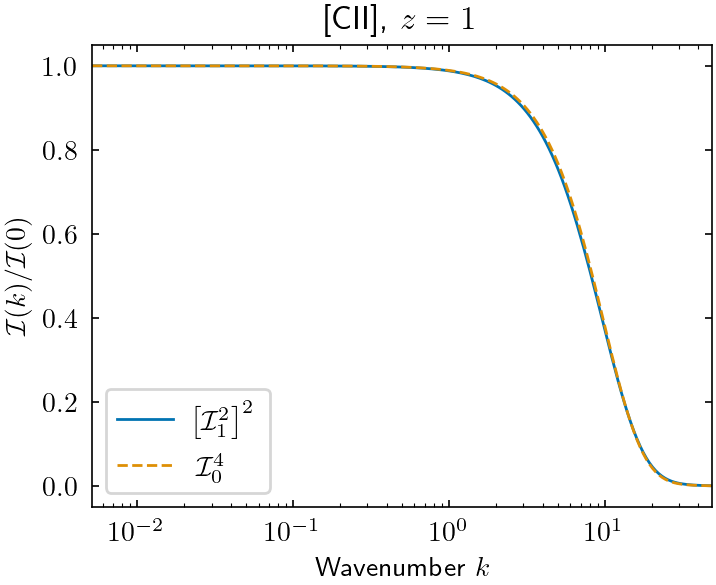

In [14]:
color = iter(Cs)

plt.semilogx(k, (I21/I21[0])**2, c=next(color), label=r"$\left[\mathcal{I}_1^2\right]^2$")
plt.semilogx(k, I40/I40[0], c=next(color), ls="--", label=r"$\mathcal{I}^4_0$")
plt.ylabel(r"$\mathcal{I}(k) / \mathcal{I}(0)$")
plt.xlabel(r"Wavenumber $k$")
plt.legend()
plt.title("[CII], $z=1$")

In [15]:
M = myastro.M
int21 = myastro.massluminosityfunction(M, 1)**2 * myastro.halomodel.halomassfunction(M, 1) * M * myastro.halomodel.get_bias(M, 1, 1)
int40 = myastro.massluminosityfunction(M, 1)**4 * myastro.halomodel.halomassfunction(M, 1) * M


/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0.5, 1.0, '[CII], $z=1$')

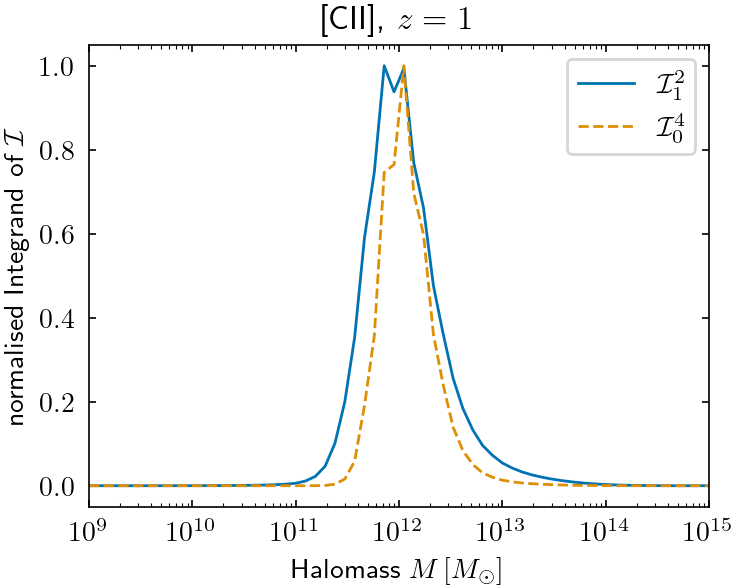

In [16]:
color = iter(Cs)

plt.semilogx(M, int21 / int21.max(), c=next(color), label=r"$\mathcal{I}_1^2$")
plt.semilogx(M, int40 / int40.max(), c=next(color), ls="--", label=r"$\mathcal{I}^4_0$")

plt.ylabel(r"normalised Integrand of $\mathcal{I}$")
plt.xlabel(r"Halomass $M\,[M_\odot]$")
plt.legend()
plt.title("[CII], $z=1$")

Text(0.5, 1.0, '[CII], $z=1$')

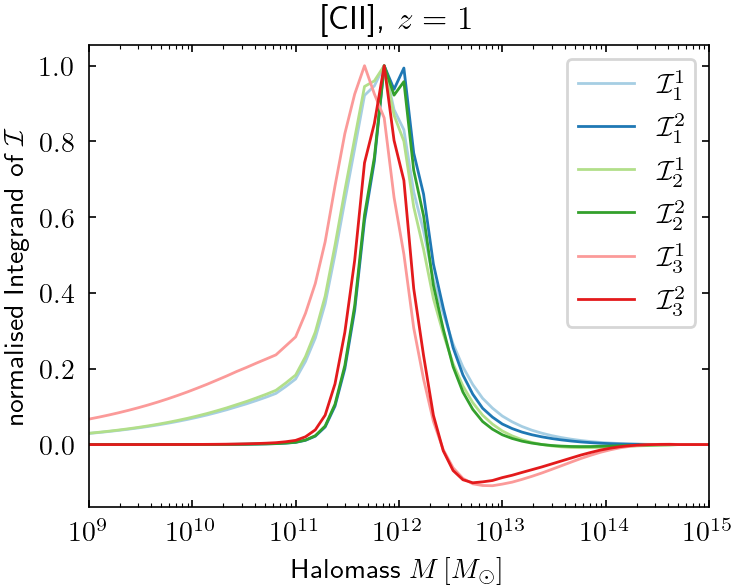

In [17]:
color = iter(Cp)
from itertools import product

alpha = [1, 2]
for b, ai in product(zip([1,2,3],[1, "b2_fitted", "b3"]), alpha):
    inta1 = myastro.massluminosityfunction(M, 1)**ai * myastro.halomodel.halomassfunction(M, 1) * M * myastro.halomodel.get_bias(M, 1, b[1])

    norm = np.abs(inta1).max() * np.sign(inta1[np.argmax(np.abs(inta1))])

    plt.semilogx(M, inta1 / norm, c=next(color), label=r"$\mathcal{{I}}_{}^{}$".format(b[0], ai))

plt.ylabel(r"normalised Integrand of $\mathcal{I}$")
plt.xlabel(r"Halomass $M\,[M_\odot]$")
plt.legend()
plt.title("[CII], $z=1$")

Text(0.5, 1.0, '[CII], $z=1$')

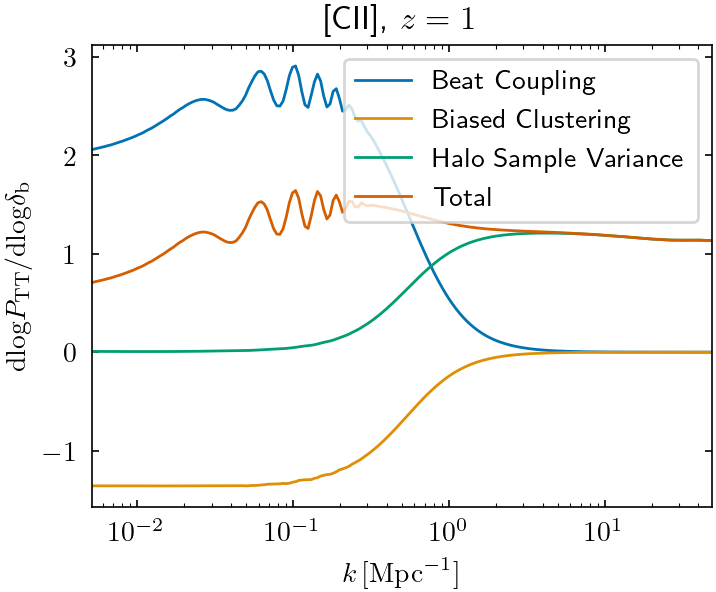

In [18]:
color = iter(Cs)

LiG = ssc_CII.linear_growth_response    (pobs_CII.k, pobs_CII.z) / pobs_CII.Pk_0bs
BiC = ssc_CII.biased_clustering_response(pobs_CII.k, pobs_CII.z) / pobs_CII.Pk_0bs
HSV = ssc_CII.halo_sample_variance      (pobs_CII.k, pobs_CII.z) / pobs_CII.Pk_0bs
plt.semilogx(pobs_CII.k, LiG, c=next(color), label="Beat Coupling")
plt.semilogx(pobs_CII.k, BiC, c=next(color), label="Biased Clustering")
plt.semilogx(pobs_CII.k, HSV, c=next(color), label="Halo Sample Variance")
plt.semilogx(pobs_CII.k, LiG + BiC + HSV, c=next(color), label="Total")
plt.legend()
plt.xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$\mathrm{dlog}P_\mathrm{TT}/\mathrm{dlog}\delta_\mathrm{b}$")
plt.title("[CII], $z=1$")

In [19]:
astrodict_CO21={
    "model_type": "ML",
    "model_name": "TonyLi",
    "model_par": {
        "alpha": 1.11,
        "beta": 0.6,
        "dMF": 1 * u.Msun * u.yr**-1 * u.Lsun**-1,
        "sig_SFR":0,
        "SFR_file": "sfr_release.dat",
        "do_quench": False,
    },
    "sigma_scatter" : 0.37,
} # CO(2-1)

nu = 2 * 115.27 * u.GHz # CO(2-1)
surveyspecs_CO21 = get_specs(np.array([1]),nu)

In [20]:
pobs_CO21 = myssl.compute(
    myssl.fiducialcosmoparams,
    myssl.fiducialhaloparams,
    astrodict_CO21,
    surveyspecs_CO21,
    pobs_settings={"mu_kind":"gauss", "kmin":5e-3 * u.Mpc**-1},
    output=["Power spectrum"],
)["Power spectrum"]
ssc_CO21 = scov.SuperSampleCovariance(pobs_CO21)

/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/fitting_functions/mass_luminosity.py:233: RuntimeWarning: divide by zero encountered in log10
  logL = np.log10(LIR.to(u.Lsun).value)
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:166: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


Text(0.5, 1.0, 'CO(2-1), $z=1$')

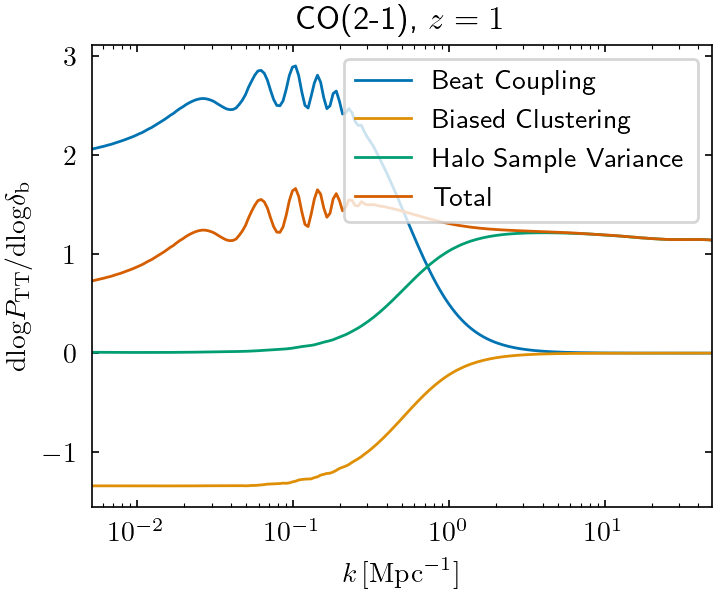

In [21]:
color = iter(Cs)

LiG = ssc_CO21.linear_growth_response    (pobs_CO21.k, pobs_CO21.z) / pobs_CO21.Pk_0bs
BiC = ssc_CO21.biased_clustering_response(pobs_CO21.k, pobs_CO21.z) / pobs_CO21.Pk_0bs
HSV = ssc_CO21.halo_sample_variance      (pobs_CO21.k, pobs_CO21.z) / pobs_CO21.Pk_0bs
plt.semilogx(pobs_CII.k, LiG, c=next(color), label="Beat Coupling")
plt.semilogx(pobs_CII.k, BiC, c=next(color), label="Biased Clustering")
plt.semilogx(pobs_CII.k, HSV, c=next(color), label="Halo Sample Variance")
plt.semilogx(pobs_CII.k, LiG + BiC + HSV, c=next(color), label="Total")
plt.legend()
plt.xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$\mathrm{dlog}P_\mathrm{TT}/\mathrm{dlog}\delta_\mathrm{b}$")
plt.title("CO(2-1), $z=1$")

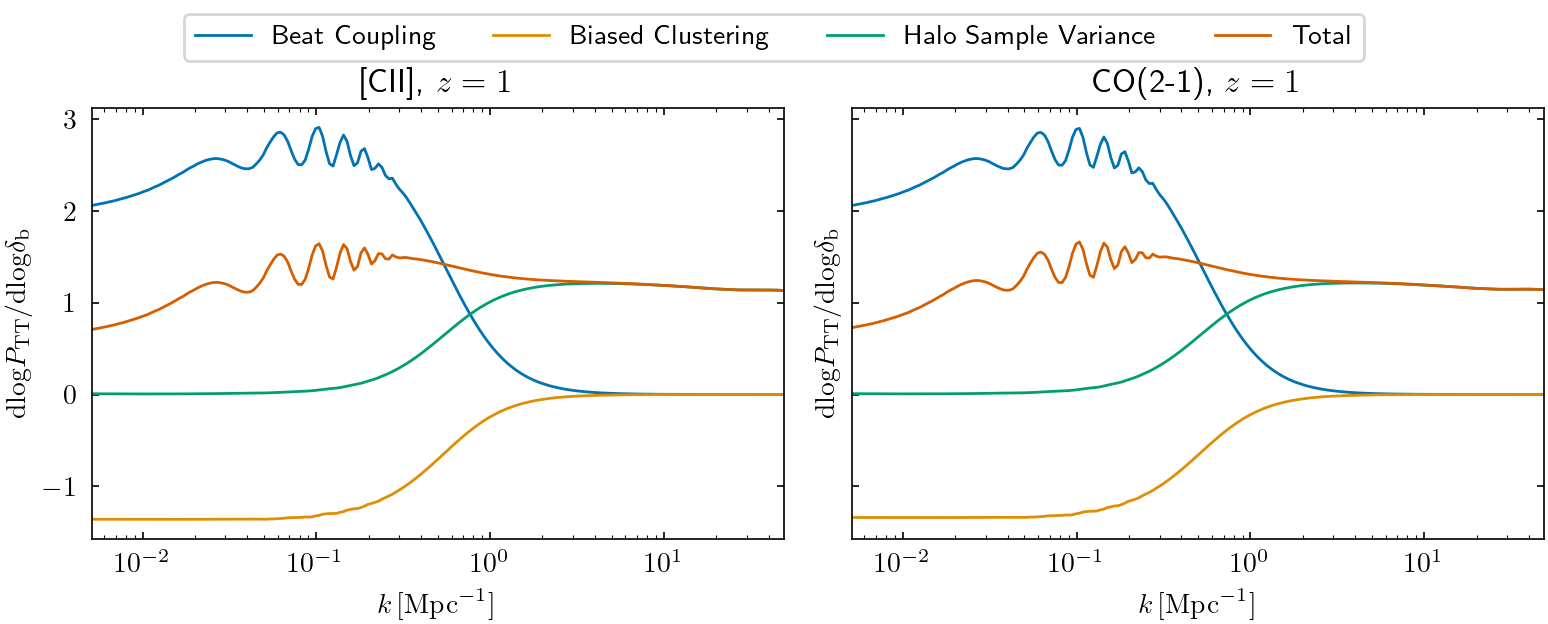

In [22]:
fw, fh=plt.rcParams['figure.figsize']
fig, axs=plt.subplots(1,2, figsize=(2*fw, 1.1*fh), sharex=True, sharey=True) 

color = iter(Cs)
LiG = ssc_CII.linear_growth_response    (pobs_CII.k, pobs_CII.z) / pobs_CII.Pk_0bs
BiC = ssc_CII.biased_clustering_response(pobs_CII.k, pobs_CII.z) / pobs_CII.Pk_0bs
HSV = ssc_CII.halo_sample_variance      (pobs_CII.k, pobs_CII.z) / pobs_CII.Pk_0bs
axs[0].semilogx(pobs_CII.k, LiG, c=next(color), label="Beat Coupling")
axs[0].semilogx(pobs_CII.k, BiC, c=next(color), label="Biased Clustering")
axs[0].semilogx(pobs_CII.k, HSV, c=next(color), label="Halo Sample Variance")
axs[0].semilogx(pobs_CII.k, LiG + BiC + HSV, c=next(color), label="Total")
axs[0].set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
axs[0].set_ylabel(r"$\mathrm{dlog}P_\mathrm{TT}/\mathrm{dlog}\delta_\mathrm{b}$")
axs[0].set_title("[CII], $z=1$")

color = iter(Cs)
LiG = ssc_CO21.linear_growth_response    (pobs_CO21.k, pobs_CO21.z) / pobs_CO21.Pk_0bs
BiC = ssc_CO21.biased_clustering_response(pobs_CO21.k, pobs_CO21.z) / pobs_CO21.Pk_0bs
HSV = ssc_CO21.halo_sample_variance      (pobs_CO21.k, pobs_CO21.z) / pobs_CO21.Pk_0bs
axs[1].semilogx(pobs_CII.k, LiG, c=next(color), label="Beat Coupling")
axs[1].semilogx(pobs_CII.k, BiC, c=next(color), label="Biased Clustering")
axs[1].semilogx(pobs_CII.k, HSV, c=next(color), label="Halo Sample Variance")
axs[1].semilogx(pobs_CII.k, LiG + BiC + HSV, c=next(color), label="Total")
axs[1].set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
axs[1].set_ylabel(r"$\mathrm{dlog}P_\mathrm{TT}/\mathrm{dlog}\delta_\mathrm{b}$")
axs[1].set_title("CO(2-1), $z=1$")

handles, labels = [], []

for ax in [axs[0]]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(handles, labels, loc='upper center', ncol=4)
plt.tight_layout(rect=[0, 0, 1, 0.93])

Neutral Hydrogen

In [23]:
astrodict_HI={
    "model_type": "ML",
    "model_name": "L_from_MHI_VN",
    "model_par": {
        "alpha": 0.53,
        "M0": 1.5e10 * myssl.current_astro.Msunh,
        "Mmin":6.0e11 * myssl.current_astro.Msunh,
        "do_quench": False,
    },
    "sigma_scatter" : 0.0,
}
nu = (c.c/ (21*u.cm)).to(u.MHz)
surveyspecs_HI = get_specs(np.array([1]), nu)

In [24]:
(1.5e10 * myssl.current_astro.Msunh * 6.25e-9 * u.Lsun / u.Msun).to(u.Lsun)

<Quantity 138.47858198 solLum>

In [25]:
pobs_HI = myssl.compute(
    myssl.fiducialcosmoparams,
    myssl.fiducialhaloparams,
    astrodict_HI,
    surveyspecs_HI,
    pobs_settings={"mu_kind":"gauss", "kmin":5e-3 * u.Mpc**-1},
    output=["Power spectrum"],
)["Power spectrum"]
ssc_HI = scov.SuperSampleCovariance(pobs_HI)

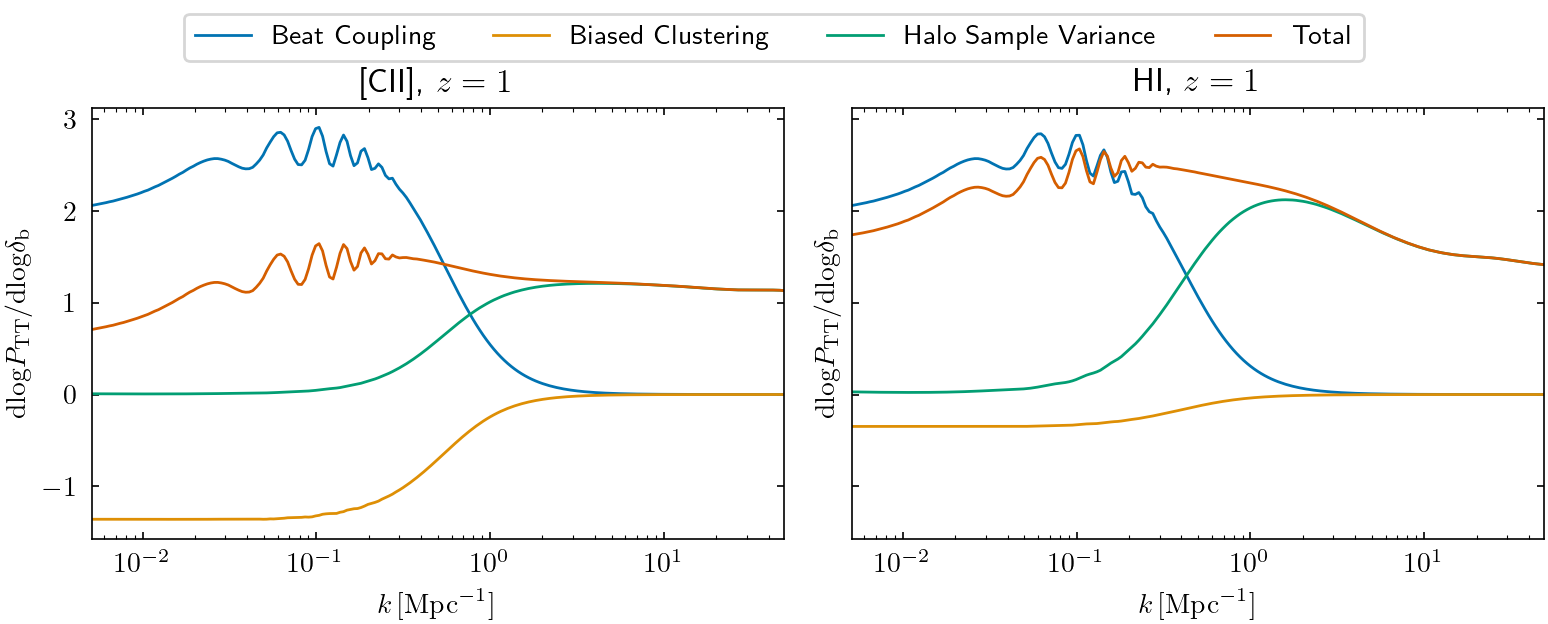

In [26]:
fw, fh=plt.rcParams['figure.figsize']
fig, axs=plt.subplots(1,2, figsize=(2*fw, 1.1*fh), sharex=True, sharey=True) 

color = iter(Cs)
LiG = ssc_CII.linear_growth_response    (pobs_CII.k, pobs_CII.z) / pobs_CII.Pk_0bs
BiC = ssc_CII.biased_clustering_response(pobs_CII.k, pobs_CII.z) / pobs_CII.Pk_0bs
HSV = ssc_CII.halo_sample_variance      (pobs_CII.k, pobs_CII.z) / pobs_CII.Pk_0bs
axs[0].semilogx(pobs_CII.k, LiG, c=next(color), label="Beat Coupling")
axs[0].semilogx(pobs_CII.k, BiC, c=next(color), label="Biased Clustering")
axs[0].semilogx(pobs_CII.k, HSV, c=next(color), label="Halo Sample Variance")
axs[0].semilogx(pobs_CII.k, LiG + BiC + HSV, c=next(color), label="Total")
axs[0].set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
axs[0].set_ylabel(r"$\mathrm{dlog}P_\mathrm{TT}/\mathrm{dlog}\delta_\mathrm{b}$")
axs[0].set_title("[CII], $z=1$")

color = iter(Cs)
LiG = ssc_HI.linear_growth_response    (pobs_HI.k, pobs_HI.z) / pobs_HI.Pk_0bs
BiC = ssc_HI.biased_clustering_response(pobs_HI.k, pobs_HI.z) / pobs_HI.Pk_0bs
HSV = ssc_HI.halo_sample_variance      (pobs_HI.k, pobs_HI.z) / pobs_HI.Pk_0bs
axs[1].semilogx(pobs_CII.k, LiG, c=next(color), label="Beat Coupling")
axs[1].semilogx(pobs_CII.k, BiC, c=next(color), label="Biased Clustering")
axs[1].semilogx(pobs_CII.k, HSV, c=next(color), label="Halo Sample Variance")
axs[1].semilogx(pobs_CII.k, LiG + BiC + HSV, c=next(color), label="Total")
axs[1].set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
axs[1].set_ylabel(r"$\mathrm{dlog}P_\mathrm{TT}/\mathrm{dlog}\delta_\mathrm{b}$")
axs[1].set_title("HI, $z=1$")

handles, labels = [], []

for ax in [axs[0]]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(handles, labels, loc='upper center', ncol=4)
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig("output/CII_vs_HI_logResponse.pdf")

# Vary Omega_field and look for covariances

In [27]:
def get_specs(z, nu, Omf):
        nuObs = nu / (z + 1)
        DeltaDeltanu = 0.05143

        surveyspecs = {
                "Tsys_NEFD": 0 * u.uK, #System temperature for instrumental shotnoise
                "Nfeeds": 19,
                "tobs": 1300 * u.h,
                "nD": 1, # Observational parameters
                "beam_FWHM": 0. * u.arcmin,
                "nu":  nu,
                "nuObs": nuObs, # Observed Frequency
                "Delta_nu": DeltaDeltanu * nuObs, # Frequency Bin
                "dnu": 0. * u.MHz, # Spectrograph resolution
                "Omega_field": Omf * u.deg**2,
        }
        return surveyspecs

ois = 1.4 * np.geomspace(1, 1e5, 6)

list_specs = [get_specs(1, 1.897 * u.THz, oi) for oi in ois]

Gcov_arr = []
Vsurvey_arr = []
NGcov_arr = []
SSC_arr = []
for specs in list_specs:
        pobs_CII = myssl.compute(
                myssl.fiducialcosmoparams,
                myssl.fiducialhaloparams,
                astrodict_CII, specs,
                pobs_settings={"mu_kind":"gauss", "kmin":5e-3 * u.Mpc**-1, "nk":50},
                output=["Power spectrum"])["Power spectrum"]
        
        Gcov_arr.append(scov.Covariance(pobs_CII).gaussian_cov()[:, 0, 0, 0])
        Vsurvey_arr.append(pobs_CII.survey_specs.Vfield())
        NGcov_arr.append(scov.nonGuassianCov(pobs_CII).compute_nG_Cov()[..., 0])
        SSC_arr.append(scov.SuperSampleCovariance(pobs_CII).compute_SSC()[..., 0])


/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/LIMsurvey/ingredients_T0.py:679: RuntimeWarning: invalid value encountered in power
  * np.power(np.abs(k1 - k2), an)


In [28]:
kcov = pobs_CII.k

In [29]:
Gcov_arr = np.array(Gcov_arr)
NGcov_arr = np.array(NGcov_arr)
SScov_arr = np.array(SSC_arr)

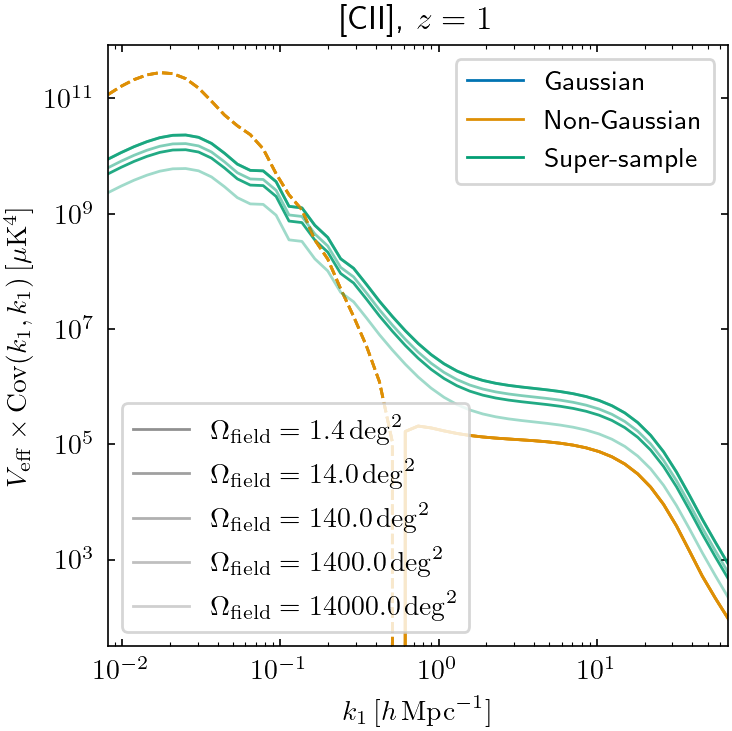

In [30]:
ois = 1.4 * np.geomspace(1, 1e4, 5)

fw, fh = plt.rcParams['figure.figsize']
fig, ax = plt.subplots(1, 1, figsize=(fw, 1.3*fh)) 

for i in range(5):
    ax.loglog(kcov.to(pobs_CII.astro.Mpch**-1), Vsurvey_arr[i] * Gcov_arr[i, ...],
              c=Cs[0], alpha=1 - (i+1)/8)
    ax.loglog(kcov.to(pobs_CII.astro.Mpch**-1), Vsurvey_arr[i] * (np.diag(NGcov_arr[i, ...])),
              c=Cs[1], alpha=1 - (i+1)/8)
    ax.loglog(kcov.to(pobs_CII.astro.Mpch**-1), Vsurvey_arr[i] * -(np.diag(NGcov_arr[i, ...])),
              c=Cs[1], alpha=1 - (i+1)/8, ls="--")
    ax.loglog(kcov.to(pobs_CII.astro.Mpch**-1), Vsurvey_arr[i] * np.diag(SScov_arr[i, ...]),
              c=Cs[2], alpha=1 - (i+1)/8)
    
    ax.plot([], [], color="grey", alpha=1 - (i+1)/8,
            label=r"$\Omega_\mathrm{field}=" + r"{}\,\mathrm{{deg}}^2$".format(ois[i]))

ax.set_xlabel(r"$k_1\,[h\,\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$V_\mathrm{eff}\times\mathrm{Cov}(k_1,k_1)\,[\mu\mathrm{K}^{4}]$")
ax.set_title("[CII], $z=1$")

# First legend (field size)
legend1 = ax.legend(loc="lower left")

# Create dummy lines for covariance types
line_G, = ax.plot([], [], color=Cs[0], label="Gaussian")
line_NG, = ax.plot([], [], color=Cs[1], label="Non-Gaussian")
line_SS, = ax.plot([], [], color=Cs[2], label="Super-sample")

# Second legend (covariance contributions)
legend2 = ax.legend(handles=[line_G, line_NG, line_SS], loc="upper right")

# Add the first legend back
ax.add_artist(legend1)

plt.show()

# Reproduce Concerto Results

In [31]:
mycosmo = pobs_CII.fiducial_cosmology

In [32]:
import multiprocessing as mp
from functools import partial
from scipy.special import spherical_jn
from scipy.integrate import dblquad

In [33]:
from scipy.integrate import lebedev_rule
points, weights = lebedev_rule(131)
kx, ky, kz = (*points,)

In [34]:
def A_of_u(k, La, Lb):
        ka = (k * La).to(1).value[:, None]
        kb = (k * Lb).to(1).value[:, None]

        Jx = spherical_jn(0, 0.5*ka*kx)
        Jy = spherical_jn(0, 0.5*ka*ky)
        Jz = spherical_jn(0, 0.5*kb*kz)

        return np.sum(weights * (Jx * Jy * Jz)**2, axis=1) / (4 * np.pi)

def get_specs(nuObs, Omf):
        nu = 1.897 * u.THz

        surveyspecs = {
                "Tsys_NEFD": 0 * u.uK, #System temperature for instrumental shotnoise
                "Nfeeds": 19,
                "tobs": 1300 * u.h,
                "nD": 1, # Observational parameters
                "beam_FWHM": 0. * u.arcmin,
                "nu":  nu,
                "nuObs": nuObs, # Observed Frequency
                "Delta_nu": 10 * u.GHz, # Frequency Bin
                "dnu": 0. * u.MHz, # Spectrograph resolution
                "Omega_field": Omf,
        }
        return surveyspecs
nus = np.geomspace(125, 305, 15) * u.GHz
ois = np.array([0.0625, 0.25, 1, 4, 9]) * u.deg**2
list_specs = [get_specs(nui, oi) for nui, oi in product(nus, ois)]

sigma_over_mu = []
sigma_survey = []
for specs in list_specs:
        pobs_CII = myssl.compute(
                myssl.fiducialcosmoparams,
                myssl.fiducialhaloparams,
                astrodict_CII, specs,
                pobs_settings={"mu_kind":"gauss", "kmin":5e-3 * u.Mpc**-1, "nk":50},
                output=["Power spectrum"])["Power spectrum"]
        
        specs_obj = pobs_CII.survey_specs
        Lfield = specs_obj.Lfield()
        Lsquare = pobs_CII.cosmology.angdist(pobs_CII.z) * np.sqrt(specs["Omega_field"]).to(u.rad).value

        k = np.geomspace(pobs_CII.k_numerics.min().value, pobs_CII.k_numerics.max().value) * pobs_CII.k_numerics.unit
        A = A_of_u(k, Lsquare, Lfield)
        sigma_integrand = 4 * np.pi * k**3 * mycosmo.matpow(k, pobs_CII.z) * A
        soverV = np.trapezoid(sigma_integrand, x=np.log(k.value)) / (2 * np.pi)**3
        sigma_survey.append(soverV)
        sscov = scov.SuperSampleCovariance(pobs_CII)
        sigma_SSC = np.sqrt(soverV) * sscov.response(pobs_CII.k, pobs_CII.z).squeeze()

        sigma_over_mu.append(sigma_SSC / pobs_CII.Pk_0bs.squeeze())
sigma_over_mu = np.array(sigma_over_mu)

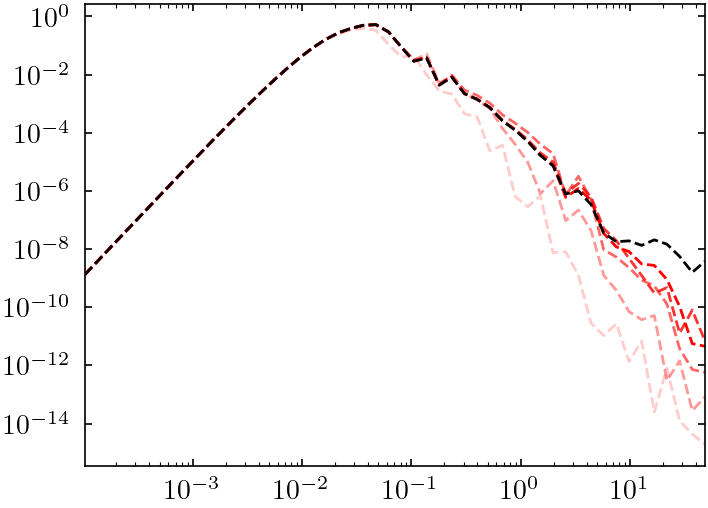

In [35]:
for i in range(1,6):

        phi2 = 2*np.pi*np.random.rand(10**i)
        cos_theta2 = 2*np.random.rand(10**i) - 1
        sin_theta2 = np.sqrt(1 - cos_theta2**2)

        def A_of_u(k, La, Lb):
                ka = (k * La).to(1).value[:, None]
                kb = (k * Lb).to(1).value[:, None]

                kx = sin_theta2 * np.cos(phi2)
                ky = sin_theta2 * np.sin(phi2)
                kz = cos_theta2

                Jx = spherical_jn(0, 0.5*ka*kx)
                Jy = spherical_jn(0, 0.5*ka*ky)
                Jz = spherical_jn(0, 0.5*kb*kz)

                return ((Jx*Jy*Jz)**2).mean(1)
        A2 = A_of_u(k, Lsquare, Lfield)

        plt.loglog(k, A2 * 4 * np.pi * k**3 * mycosmo.matpow(k, pobs_CII.z), "r--", alpha=0.2 * i)

plt.loglog(k, A * 4 * np.pi * k**3 * mycosmo.matpow(k, pobs_CII.z), "k--")

In [36]:
sigma_survey = np.array(sigma_survey)
sigma_survey

array([0.01500612, 0.0119086 , 0.00853713, 0.00531772, 0.00371643,
       0.01523558, 0.01201854, 0.00853383, 0.00524766, 0.00363714,
       0.01546694, 0.01212201, 0.00852573, 0.00517356, 0.00355718,
       0.01569959, 0.01221963, 0.00851142, 0.00509604, 0.00347333,
       0.01593834, 0.012317  , 0.00849426, 0.0050204 , 0.00338934,
       0.01617839, 0.01241453, 0.00847525, 0.0049465 , 0.00330828,
       0.01641738, 0.01250926, 0.00845313, 0.00487037, 0.00323003,
       0.01665601, 0.01259906, 0.00842822, 0.00479192, 0.00315396,
       0.01689545, 0.01268491, 0.00840105, 0.00471298, 0.00307813,
       0.01713502, 0.01276666, 0.00836895, 0.00463408, 0.0030005 ,
       0.01737466, 0.01284638, 0.00833273, 0.00455605, 0.00292232,
       0.01761269, 0.01292365, 0.00829279, 0.00447744, 0.00284506,
       0.01785625, 0.01300396, 0.0082551 , 0.00439836, 0.00277062,
       0.01810884, 0.01308878, 0.00822376, 0.00432341, 0.00270181,
       0.01836929, 0.01317694, 0.00819769, 0.00425416, 0.00263

In [37]:
sscov.sigma_survey()

array(0.00012482)

In [38]:
fmask = ~np.any(np.isnan(sigma_over_mu), axis=1)
fmask.shape

(75,)

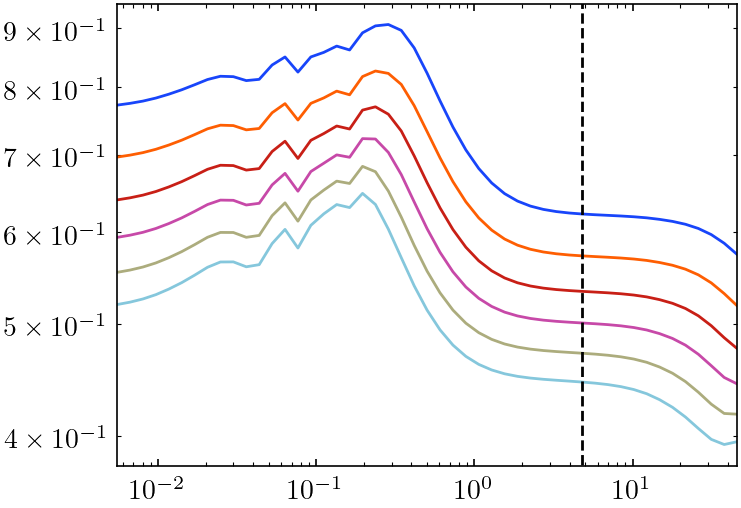

In [39]:
plt.loglog(pobs_CII.k, sigma_over_mu[fmask, :][2::5, :].T)
plt.vlines(pobs_CII.k[36].value, 0.2, 1, ls="--", color="k")

In [40]:
def concerto(nu, dnu, om, c, alpha, beta, gamma):
    A = (nu / (100 * u.GHz)).to(1).value
    B = (dnu / (5 * u.GHz)).to(1).value
    C = (om / (1 * u.deg**2)).to(1).value
    return c * A**alpha * B**beta * C**gamma

In [41]:
c = concerto(nus[9:], 10* u.GHz, ois[:, None], 6.22, -2.4, -0.61, -0.46).T

In [42]:
poision = sigma_over_mu[fmask, :].reshape((6, 5, 49))[:, :, 36] 
poision.shape

(6, 5)

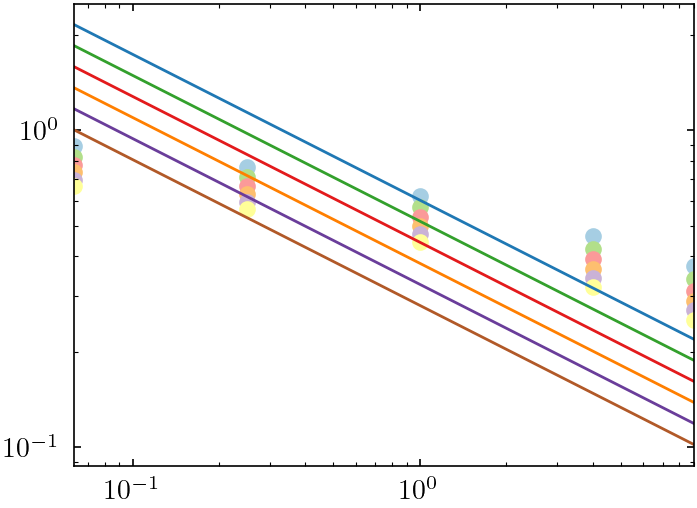

In [43]:
color = iter(Cp)
for i in range(6):
    plt.scatter(ois, poision[i, :], color=next(color))
    plt.loglog(ois,  c[i, :], color=next(color))

Text(0, 0.5, 'Relative Error')

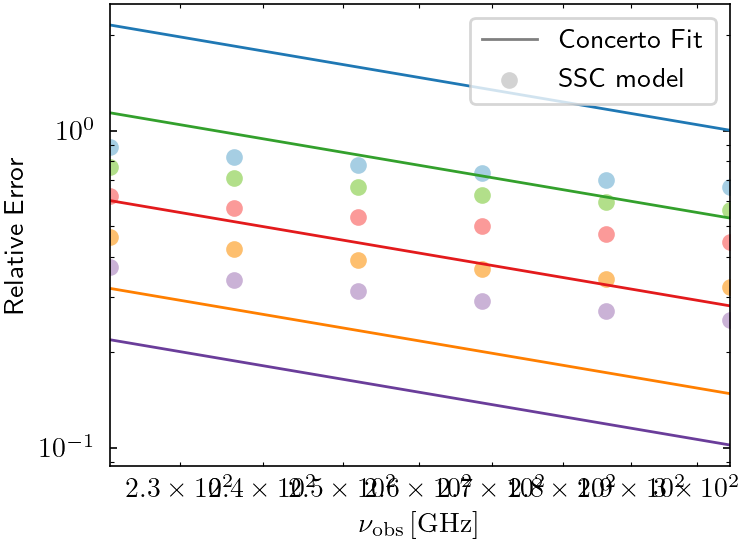

In [44]:
color = iter(Cp)
for i in range(5):
    plt.scatter(nus[9:].value, poision[:, i], color=next(color))
    plt.loglog( nus[9:].value,  c[:, i], color=next(color))

plt.loglog([],[], color="grey", label="Concerto Fit")
plt.scatter([],[], color="lightgrey", label="SSC model")
plt.legend()

plt.xlabel(r"$\nu_{\rm obs}\,[\mathrm{GHz}]$")
plt.ylabel(r"Relative Error")

In [45]:
W = specs_obj.Wsurvey(k, pobs_CII.mu) / specs_obj.Vfield()
W = np.sum(pobs_CII.w * (specs_obj.Wsurvey(k, pobs_CII.mu) / specs_obj.Vfield())**2, axis=1)


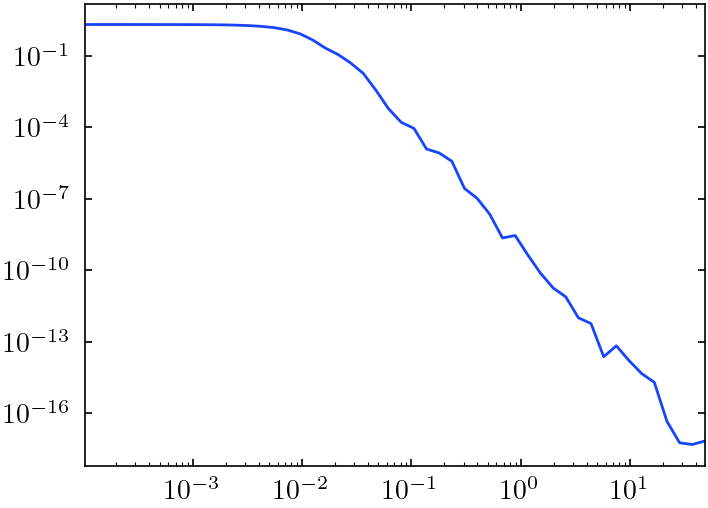

In [46]:
plt.loglog(k, W)